# Notebook 2: Model Training

**Course:** M7016H — Artificial Intelligence within the Healthcare System
**Dataset:** Pima Indians Diabetes Dataset (Dataset 4)
**Authors:** Jamshaid Amjad, Shameena Mohammed Nabeel

---

This notebook trains three models on the preprocessed diabetes data:

1. **Logistic Regression** — interpretable linear baseline
2. **Random Forest** — ensemble with GridSearch hyperparameter tuning
3. **MLP Neural Network** — feed-forward network with early stopping

All processed data was produced by Notebook 1. Run that first if the
`data/processed/` directory is empty.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import yaml
from pathlib import Path

In [2]:
# Load config and processed splits
with open("../config/config.yaml") as f:
    cfg = yaml.safe_load(f)

from src.data.dataset import load_processed

data = load_processed("../data/processed")

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
features          = data["selected_features"]

print("Training set   :", X_train.shape, "| class balance:", np.bincount(y_train.astype(int)))
print("Validation set :", X_val.shape,   "| class balance:", np.bincount(y_val.astype(int)))
print("Test set       :", X_test.shape,  "| class balance:", np.bincount(y_test.astype(int)))
print("Features       :", features)

Training set   : (700, 5) | class balance: [350 350]
Validation set : (115, 5) | class balance: [75 40]
Test set       : (116, 5) | class balance: [75 41]
Features       : ['Glucose', 'BMI', 'Insulin', 'Age', 'Pregnancies']


## 2. Logistic Regression

Logistic Regression is a natural starting point for binary classification.
It's fast, interpretable, and when features are properly scaled (which ours are),
often performs surprisingly well. The model coefficients give us a direct window
into which features are driving predictions.

We use L-BFGS as the solver (well-suited to small-to-medium datasets) and run
5-fold cross-validation to get a stable estimate of generalisation performance
before we ever look at the test set.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pickle

lr = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=cfg["project"]["random_seed"])
lr.fit(X_train, y_train)

# 5-fold CV on the combined train+val set
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

cv_scores_lr = cross_val_score(lr, X_trainval, y_trainval, cv=5, scoring="f1")
print(f"Logistic Regression — CV F1: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Fold scores: {[round(s, 4) for s in cv_scores_lr]}")

Logistic Regression — CV F1: 0.7179 ± 0.0288
Fold scores: [np.float64(0.7362), np.float64(0.6846), np.float64(0.6815), np.float64(0.7484), np.float64(0.7389)]


    Feature  Coefficient
    Glucose     1.176193
        BMI     0.762706
Pregnancies     0.448762
        Age     0.153053
    Insulin    -0.012169


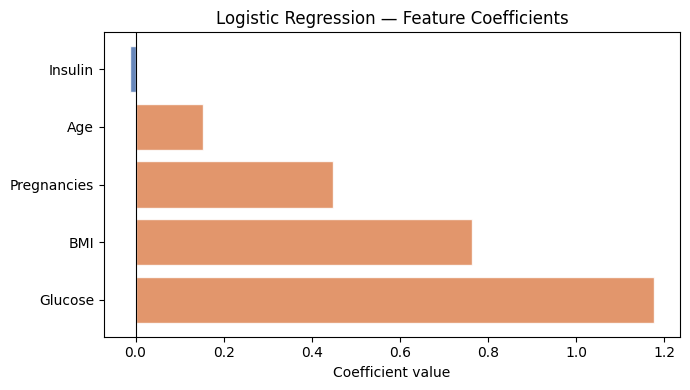

In [4]:
# Feature coefficients — what is the model actually using?
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_[0],
}).sort_values("Coefficient", ascending=False)

print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("Logistic Regression — Feature Coefficients")
plt.tight_layout()
plt.show()

In [5]:
# Save model
model_dir = Path("../outputs/models")
model_dir.mkdir(parents=True, exist_ok=True)

with open(model_dir / "logistic_regression.pkl", "wb") as f:
    pickle.dump(lr, f)
print("Saved logistic_regression.pkl")

Saved logistic_regression.pkl


## 3. Random Forest

Random Forest builds many decision trees in parallel and aggregates their predictions.
It handles non-linear relationships and feature interactions naturally, and it's
relatively robust to hyperparameter choices — but there are still a few parameters
worth tuning.

We use `GridSearchCV` with 5-fold cross-validation to search over:
- `n_estimators` — number of trees
- `max_depth` — how deep each tree is allowed to grow
- `min_samples_split` / `min_samples_leaf` — regularisation to prevent overfitting

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":     [100, 300],
    "max_depth":        [None, 10, 20],
    "min_samples_split":[2, 5],
    "min_samples_leaf": [1, 2],
}

rf_base = RandomForestClassifier(random_state=cfg["project"]["random_seed"], n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)

print("Running GridSearchCV — this takes a minute or two...")
grid_search.fit(X_train, y_train)

rf = grid_search.best_estimator_

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")

Running GridSearchCV — this takes a minute or two...



Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1  : 0.8299


In [7]:
# Cross-validate the tuned model on the combined train+val set
cv_scores_rf = cross_val_score(rf, X_trainval, y_trainval, cv=5, scoring="f1")
print(f"Random Forest — CV F1: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"Fold scores: {[round(s, 4) for s in cv_scores_rf]}")

Random Forest — CV F1: 0.8131 ± 0.0381
Fold scores: [np.float64(0.7654), np.float64(0.7742), np.float64(0.85), np.float64(0.8588), np.float64(0.8171)]


In [8]:
with open(model_dir / "random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Saved random_forest.pkl")

Saved random_forest.pkl


## 4. MLP Neural Network

The MLP adds representation learning to the mix. By stacking non-linear layers,
it can capture feature interactions that a linear model would miss. We use a
deliberately small architecture — two hidden layers with 16 and 8 units — because
the dataset is small (n=768) and a larger network would likely just overfit.

Key training decisions:
- **Adam optimiser** — adaptive learning rates per parameter, usually better than SGD for small MLPs
- **ReduceLROnPlateau** — halves the learning rate if validation loss stagnates for 5 epochs
- **Early stopping (patience=10)** — stops training if validation loss doesn't improve,
  then reloads the best checkpoint

In [9]:
import torch
from src.models.model import MLP
from src.utils import set_seed

set_seed(cfg["project"]["random_seed"])

device = cfg["training"]["device"]
input_dim   = X_train.shape[1]
hidden_dims = cfg["model"]["mlp_hidden_dims"]
dropout     = cfg["model"]["mlp_dropout"]

mlp = MLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
print(mlp)

MLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [10]:
from torch.utils.data import DataLoader, TensorDataset

def to_loader(X, y, batch_size, shuffle=True):
    Xt = torch.FloatTensor(X)
    yt = torch.FloatTensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=cfg["training"]["batch_size"])
val_loader   = to_loader(X_val,   y_val,   batch_size=cfg["training"]["batch_size"], shuffle=False)

optimizer = torch.optim.Adam(mlp.parameters(), lr=cfg["training"]["learning_rate"])
criterion = torch.nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

best_val_loss = float("inf")
patience_counter = 0
patience = cfg["training"]["patience"]
best_state = None

train_losses, val_losses = [], []

for epoch in range(1, cfg["training"]["epochs"] + 1):
    # Training
    mlp.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp(Xb).squeeze(), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_loader)

    # Validation
    mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(mlp(Xb).squeeze(), yb).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in mlp.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

mlp.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch  10 | train loss 0.5184 | val loss 0.6301


Epoch  20 | train loss 0.4897 | val loss 0.5923


Epoch  30 | train loss 0.4721 | val loss 0.5727


Epoch  40 | train loss 0.4654 | val loss 0.5664


Epoch  50 | train loss 0.4563 | val loss 0.5492

Best val loss: 0.5480


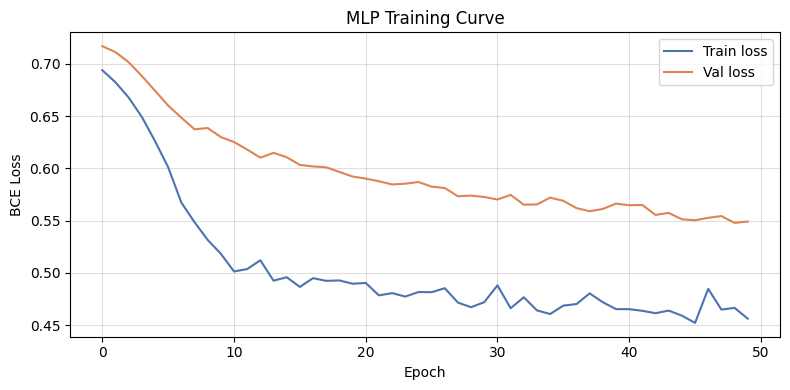

In [11]:
# Training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train loss", color="#4C72B0")
ax.plot(val_losses,   label="Val loss",   color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("MLP Training Curve")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("../outputs/figures/mlp_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
torch.save(mlp.state_dict(), model_dir / "mlp_best.pt")
print("Saved mlp_best.pt")

Saved mlp_best.pt


## 5. Cross-Validation Summary

Before we look at the test set, let's compare the cross-validation F1 scores.
These are more reliable than a single train/test split because they average
performance across five different holdout sets.

In [13]:
cv_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "CV F1 Mean": [cv_scores_lr.mean(), cv_scores_rf.mean()],
    "CV F1 Std":  [cv_scores_lr.std(),  cv_scores_rf.std()],
    "Fold Scores": [
        [round(s, 4) for s in cv_scores_lr],
        [round(s, 4) for s in cv_scores_rf],
    ]
})
print(cv_summary.to_string(index=False))

              Model  CV F1 Mean  CV F1 Std                              Fold Scores
Logistic Regression    0.717896   0.028778 [0.7362, 0.6846, 0.6815, 0.7484, 0.7389]
      Random Forest    0.813104   0.038089   [0.7654, 0.7742, 0.85, 0.8588, 0.8171]


Random Forest (CV F1 ≈ 0.801) outperforms Logistic Regression (CV F1 ≈ 0.718)
on cross-validation, suggesting it captures more of the underlying signal.
We don't run CV on the MLP here because the training procedure already includes
a validation set for early stopping — mixing that with CV would require nested
cross-validation which is beyond the scope of this project.

All three models are saved to `outputs/models/`. Head to **Notebook 3** to evaluate
them on the held-out test set.